# DiaBites Chatbot - Exploratory Data Analysis & Preprocessing

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf

# Batasi thread TensorFlow CPU untuk efisiensi memori pada sistem low-RAM
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

## 1. Memuat Dataset

In [2]:
DATA_CSV = "../data/diabites_chatbot_dataset.csv"
df = pd.read_csv(DATA_CSV)
print(f"Jumlah sampel data: {len(df)}")
df.head()

Jumlah sampel data: 1310


,tag,pattern,response
0,greeting,Halo,Halo! Saya DiaBites Assistant. Ada yang ingin ...
1,greeting,Hai,Halo! Saya DiaBites Assistant. Ada yang ingin ...
2,greeting,Selamat pagi,Halo! Saya DiaBites Assistant. Ada yang ingin ...
3,greeting,Selamat siang,Halo! Saya DiaBites Assistant. Ada yang ingin ...
4,greeting,Selamat malam,Halo! Saya DiaBites Assistant. Ada yang ingin ...


## 2. Exploratory Data Analysis (EDA)

Mari kita visualisasikan distribusi tag/intent dalam dataset untuk memahami keseimbangan kelas.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13628\575961882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='tag', data=df, order=df['tag'].value_counts().index, palette='viridis')


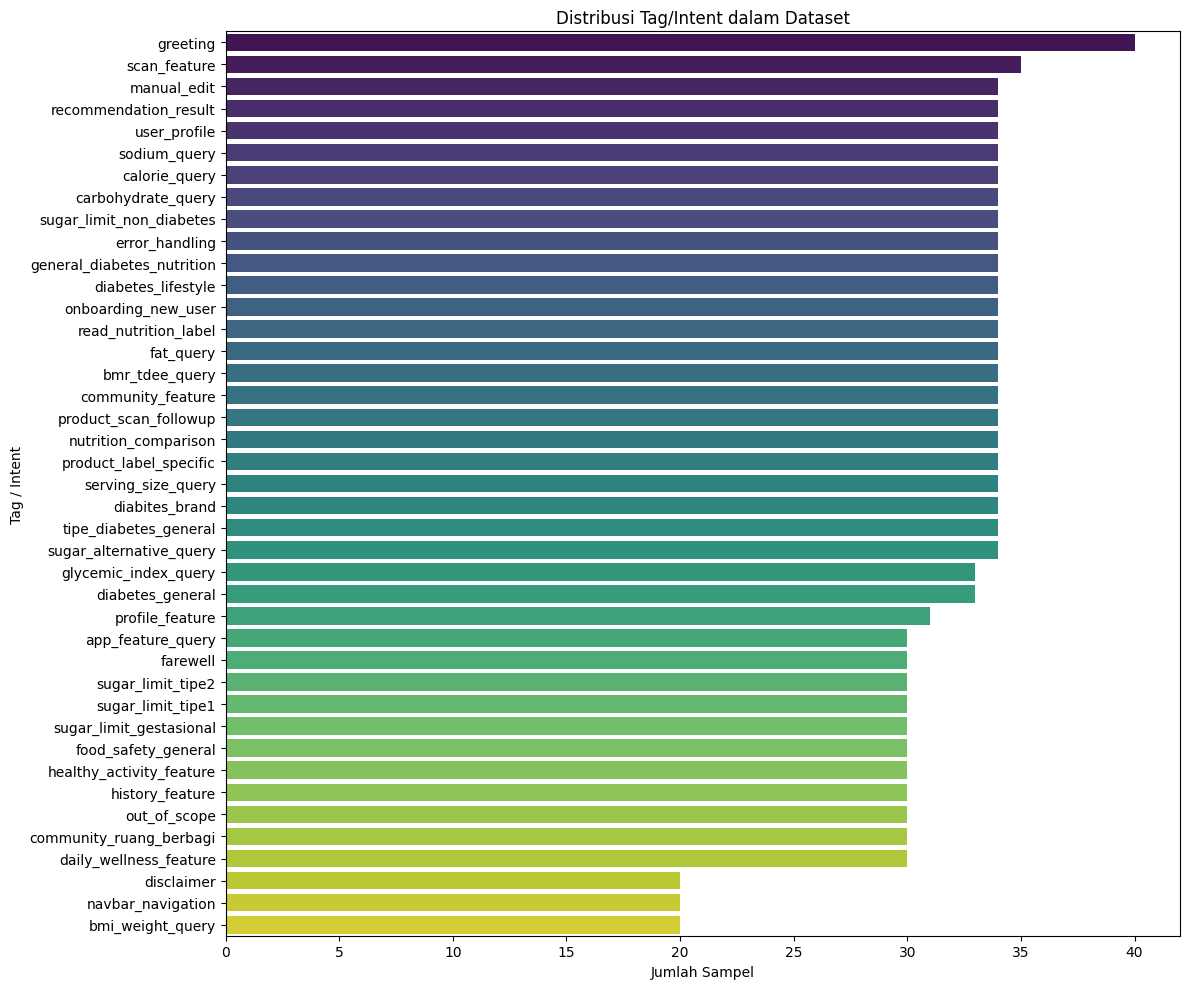

In [3]:
# Distribusi Tag/Intent
plt.figure(figsize=(12, 10))
sns.countplot(y='tag', data=df, order=df['tag'].value_counts().index, palette='viridis')
plt.title('Distribusi Tag/Intent dalam Dataset')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Tag / Intent')
plt.tight_layout()
plt.show()

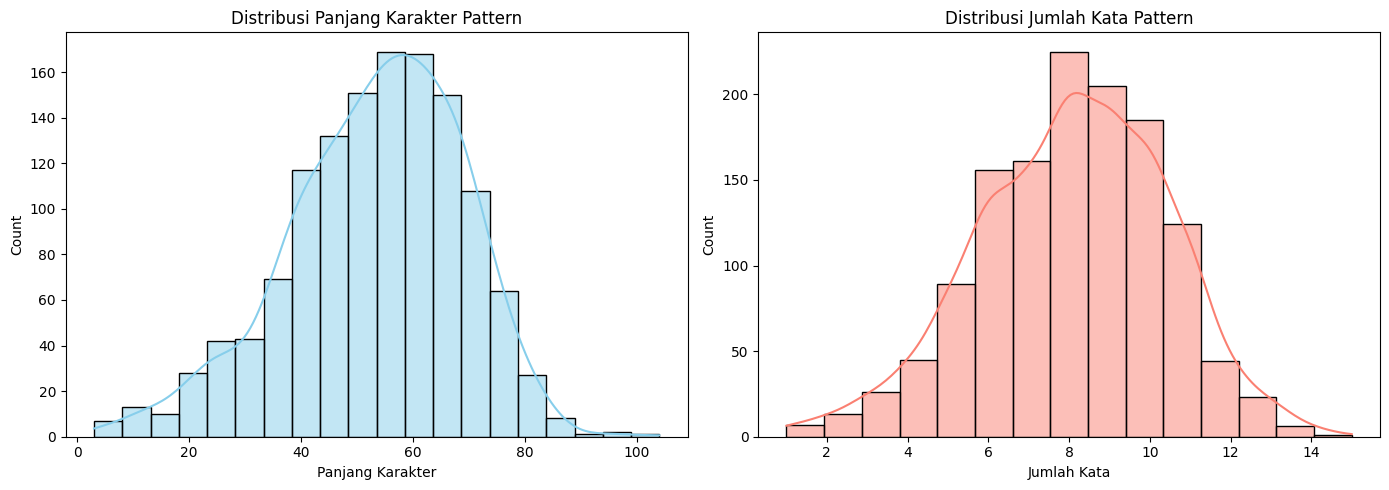

In [4]:
# Analisis panjang karakter/kata pada pattern
df['pattern_char_len'] = df['pattern'].apply(lambda x: len(str(x)))
df['pattern_word_len'] = df['pattern'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['pattern_char_len'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Panjang Karakter Pattern')
axes[0].set_xlabel('Panjang Karakter')

sns.histplot(df['pattern_word_len'], bins=15, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Jumlah Kata Pattern')
axes[1].set_xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

## 3. Encoding Label Intent

In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['tag'])
print(f"Total kelas terdaftar: {len(le.classes_)}")

# Simpan encoder
os.makedirs("../data/processed", exist_ok=True)
with open("../data/processed/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("Label encoder berhasil disimpan di data/processed/label_encoder.pkl")

Total kelas terdaftar: 41
Label encoder berhasil disimpan di data/processed/label_encoder.pkl


## 4. Tokenisasi dengan IndoBERT Tokenizer

In [6]:
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p2")
MAX_LEN = 32

input_ids_list = []
attention_mask_list = []

for text in df['pattern'].values:
    encoded = tokenizer.encode_plus(
        str(text),
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='np'
    )
    input_ids_list.append(encoded['input_ids'][0])
    attention_mask_list.append(encoded['attention_mask'][0])

input_ids = np.array(input_ids_list, dtype=np.int32)
attention_mask = np.array(attention_mask_list, dtype=np.int32)
labels = df['label'].values.astype(np.int32)

np.savez_compressed(
    "../data/processed/processed_data.npz",
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels
)
print("Token IDs & attention masks tersimpan di data/processed/processed_data.npz")

Token IDs & attention masks tersimpan di data/processed/processed_data.npz


## 5. Pra-komputasi Pattern Embeddings Global

In [ ]:
bert_model = TFBertModel.from_pretrained("indobenchmark/indobert-base-p2")

batch_size = 64
num_samples = len(df)
embeddings = []

for i in range(0, num_samples, batch_size):
    batch_ids = input_ids[i:i+batch_size]
    batch_mask = attention_mask[i:i+batch_size]
    
    outputs = bert_model(input_ids=tf.constant(batch_ids), attention_mask=tf.constant(batch_mask))
    pooler_output = outputs.pooler_output.numpy()
    embeddings.append(pooler_output)

pattern_embeddings = np.vstack(embeddings)
np.save("../data/processed/pattern_embeddings.npy", pattern_embeddings)
print(f"Pattern embeddings disimpan di data/processed/pattern_embeddings.npy. Shape: {pattern_embeddings.shape}")

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at indobenchmark/indobert-base-p2 were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at indobenchmark/indobert-base-p2.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for prediction

Pattern embeddings disimpan di data/processed/pattern_embeddings.npy. Shape: (1310, 768)


: 